# Extended Data Fig. 2 | Temporal dynamics of mangrove area in the ten major mangrove-holding countries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

In [28]:
os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\Tables\Ours')
df = pd.read_csv('ByCountry_AnnualTotal.csv')
top_10 = df.nlargest(10, '1984')

years = [str(year) for year in range(1984, 2024)]
df_melted = top_10.melt(id_vars=['Region'], value_vars=years, var_name='Year', value_name='Area')
df_melted['Year'] = df_melted['Year'].astype(int)

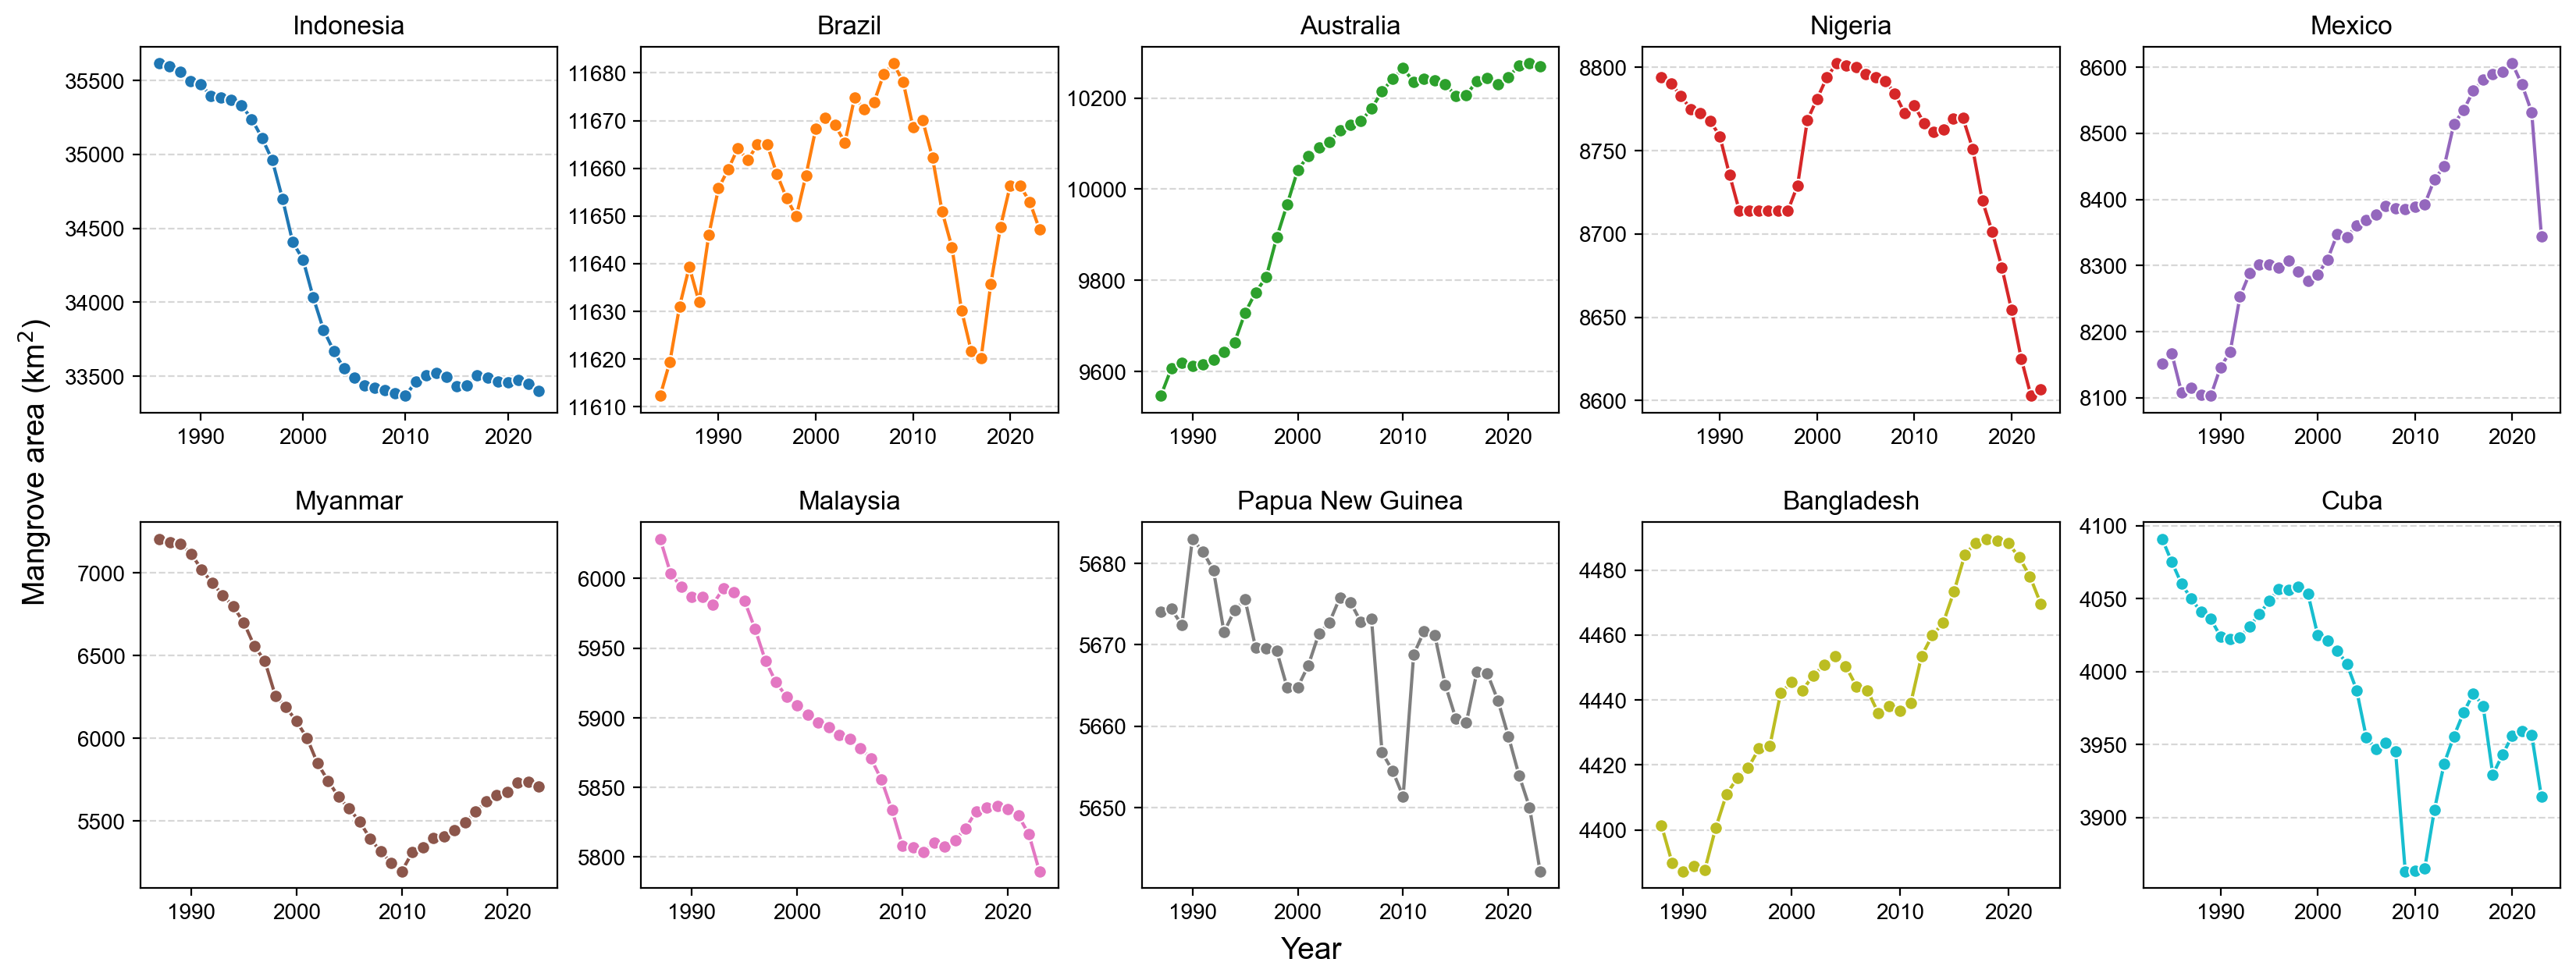

In [ ]:
fig = plt.figure(figsize=(20,7))
gs = GridSpec(nrows=2, ncols=5,figure=fig)

start_index = [2,0,3,0,0,3,3,3,4,0] # Define first valid year for each region
for i,region in enumerate(top_10.Region):
    if i < 5:
        ax = fig.add_subplot(gs[0, i])
    else:
        ax = fig.add_subplot(gs[1, i-5])

    continent_data = df_melted[df_melted['Region'] == region][start_index[i]:]
    sns.lineplot(data=continent_data, x='Year', y='Area', marker='o',ax=ax,c=f'C{i}',)
    ax.set_title(region)
    ax.set_ylabel('');ax.set_xlabel('')
    ax.grid(axis='y',ls='--',alpha=0.5)

fig.supylabel("Mangrove area (km$^2$)", fontsize=14, x= 0.085)
fig.supxlabel("Year", fontsize=14, y= 0.04)

plt.subplots_adjust(hspace = 0.3)

plt.savefig(r"D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\Figures\Top10_timeseries.png", dpi=500, format='png', bbox_inches='tight')
plt.savefig(r"D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\Figures\Top10_timeseries.svg", dpi=500, format='svg', bbox_inches='tight')